# ReservoirScope
## IND320 – Data to Decision
### Compulsory Project Work – Part 1

ReservoirScope is an interactive data analytics project for exploring Norwegian
reservoir data using Python, Pandas, data visualisation, and Streamlit.

The purpose of this notebook is to document the data preparation and exploratory
analysis used as the foundation for the ReservoirScope Streamlit application.

The notebook covers:

- loading the reservoir dataset,
- inspecting its structure and quality,
- translating column names into clear English labels,
- preparing date and numerical variables,
- exploring the dataset through descriptive statistics and visualisation,
- plotting individual variables,
- comparing variables with different scales,
- documenting the development process and AI usage.

## 1. Imports

The analysis uses Pandas for data manipulation and Matplotlib for visualisation.
Additional libraries can be added later if required by subsequent parts of the
project.

In [58]:
# Import Pandas for loading, inspecting, and manipulating tabular data.
import pandas as pd

# Import Matplotlib for creating static visualisations in the notebook.
import matplotlib.pyplot as plt

## 2. Loading the Dataset

The reservoir dataset is stored locally in `reservoirs.csv`.
It is loaded into a Pandas DataFrame so that the data can be inspected,
cleaned, transformed, and visualised.

The original dataset is preserved in the CSV file, while transformations are
performed on the DataFrame in memory.

In [59]:
# Load the local CSV file into a Pandas DataFrame.
reservior_df = pd.read_csv("reservoirs.csv")

# Display the first five rows to confirm that the file was loaded correctly.
reservior_df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Initial Dataset Inspection

Before modifying the dataset, its structure and quality are examined.

This includes:

- the number of rows and columns,
- original column names,
- data types,
- missing values,
- duplicate rows,
- and a sample of the observations.

This step helps identify any cleaning or preparation required before analysis.

In [60]:
# Show the dimensions of the dataframe
reservior_df.shape

(14877, 11)

In [61]:
# Display the original column names exactly as they appear in the CSV file.
print("Original columns:")
for column in reservior_df.columns:
    print("-", column)

Original columns:
- dato_Id
- omrType
- omrnr
- iso_aar
- iso_uke
- fyllingsgrad
- kapasitet_TWh
- fylling_TWh
- neste_Publiseringsdato
- fyllingsgrad_forrige_uke
- endring_fyllingsgrad


In [62]:
# Display the data type and number of non-null values for each column.
reservior_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


In [63]:
# Check missing values
reservior_df.isnull().sum()

dato_Id                     0
omrType                     0
omrnr                       0
iso_aar                     0
iso_uke                     0
fyllingsgrad                0
kapasitet_TWh               0
fylling_TWh                 0
neste_Publiseringsdato      0
fyllingsgrad_forrige_uke    0
endring_fyllingsgrad        0
dtype: int64

In [64]:
# Count fully duplicated rows in the dataset.
duplicate_count = reservior_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [65]:
# Display a small sample of the raw dataset.
reservior_df.head(10)

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


## 4. Renaming Columns

The original dataset uses Norwegian variable names.

For readability and consistency throughout the notebook and Streamlit
application, the headers are renamed using descriptive English names.

Only the column labels are changed; the underlying data values remain
unchanged.

In [66]:
# Rename Norwegian column names to descriptive English equivalents.
reservior_df = reservior_df.rename(
    columns = {
        'dato_Id': "date",
        'omrType': "area_type",
        'omrnr': "area_number",
        'iso_aar': "year",
        'iso_uke': "week",
        'fyllingsgrad': "fill_level",
        'kapasitet_TWh': "capacity_TWh",
        'fylling_TWh': "stored_energy_TWh",
        'neste_Publiseringsdato': "next_publication_date",
        'fyllingsgrad_forrige_uke': "previous_week_fill_level",
        'endring_fyllingsgrad': "change_in_fill_level"
    }
)

# Inspecting that the column names have been updated.
reservior_df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 5. Data Preparation

### 5.1 DateTime Conversion
The date-related columns are converted from text into Pandas datetime objects.

Using proper datetime types makes it possible to:

- sort observations chronologically,
- filter by date,
- extract time components,
- and use dates naturally in visualisations.


In [67]:
# Convert the observation date into a Pandas datetime object.
reservior_df["date"] = pd.to_datetime(reservior_df["date"])

# Convert the next publication date into a datetime object.
reservior_df["next_publication_date"] = pd.to_datetime(reservior_df["next_publication_date"])

# inspection
reservior_df.dtypes


date                        datetime64[us]
area_type                              str
area_number                          int64
year                                 int64
week                                 int64
fill_level                         float64
capacity_TWh                       float64
stored_energy_TWh                  float64
next_publication_date       datetime64[us]
previous_week_fill_level           float64
change_in_fill_level               float64
dtype: object

In [68]:
# Check whether date conversion introduced any missing values.
date_missing = reservior_df[["date", "next_publication_date"]].isna().sum()

date_missing

date                     0
next_publication_date    0
dtype: int64

### 5.2 Chronological Ordering

Because the dataset represents weekly reservoir observations, the rows are
sorted by date before time-based analysis and plotting.

A reset index is used so that the DataFrame has a clean sequential index after
sorting.

In [69]:
# Sort observations chronologically and reset the row index.
reservior_df = reservior_df.sort_values("date").reset_index(drop=True)

# Display the earliest observations after sorting.
reservior_df.head()

,date,area_type,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,1-01-01,0.614288,0.002160
1,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,1-01-01,0.801348,-0.242484
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,1-01-01,0.596027,0.006349
3,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,1-01-01,0.734888,-0.113421
4,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,1-01-01,0.777604,-0.146657


## 6. Data Overview

A concise overview is created to understand the temporal coverage and basic
structure of the reservoir dataset.

This includes:

- the observation period,
- the number of years represented,
- the available area types,
- and the available area identifiers.

In [70]:
# Summarise the main characteristics of the dataset.
print(f"Number of observations: {len(reservior_df):,}")
print(f"Start date: {reservior_df['date'].min().date()}")
print(f"End date: {reservior_df['date'].max().date()}")
print(f"Number of years represented: {reservior_df['year'].nunique()}")
print(f"Area types: {sorted(reservior_df['area_type'].dropna().unique())}")

# Convert area numbers to standard Python integers.
area_numbers = sorted(
    int(value)
    for value in reservior_df["area_number"].dropna().unique()
)

print(f"Area numbers: {area_numbers}")


Number of observations: 14,877
Start date: 1995-01-08
End date: 2026-09-06
Number of years represented: 32
Area types: ['EL', 'NO', 'VASS']
Area numbers: [0, 1, 2, 3, 4, 5]


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution and
structure of the reservoir variables before they are visualised in the
Streamlit application.

The analysis focuses on:

- descriptive statistics,
- categorical distributions,
- ranges of reservoir measurements,
- and changes over time.

The goal is exploratory understanding rather than predictive modelling.

In [71]:
# display statistics
reservior_df.describe()

,date,area_number,year,week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,previous_week_fill_level,change_in_fill_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0484-02-28 12:07:22.105272,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0001-01-01 00:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0001-01-01 00:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0001-01-01 00:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0001-01-01 00:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


### 7.1 Area Types

The `area_type` variable identifies different geographical or aggregation
categories in the dataset.

The number of observations within each category is inspected to understand how
the dataset is distributed.

In [72]:
# Count the number of observations for each area type.
area_type_counts = reservior_df["area_type"].value_counts()

area_type_counts

area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64

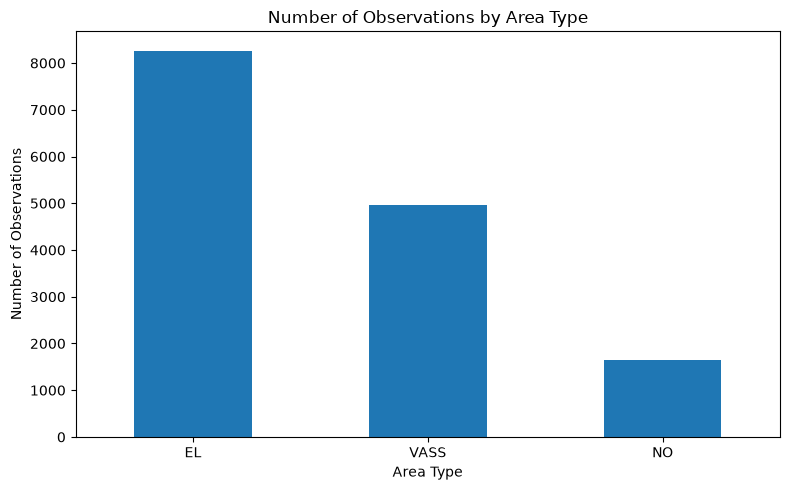

In [73]:
# Visualise the number of observations for each area type.
area_type_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Observations by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.2 Area Numbers

The distribution of observations across `area_number` is examined to identify
the geographical units represented in the dataset.

In [74]:
# Count observations for each area number.
area_number_counts = (
    reservior_df["area_number"]
    .value_counts()
    .sort_index()
)

area_number_counts

area_number
0    1653
1    3306
2    3306
3    3306
4    1653
5    1653
Name: count, dtype: int64

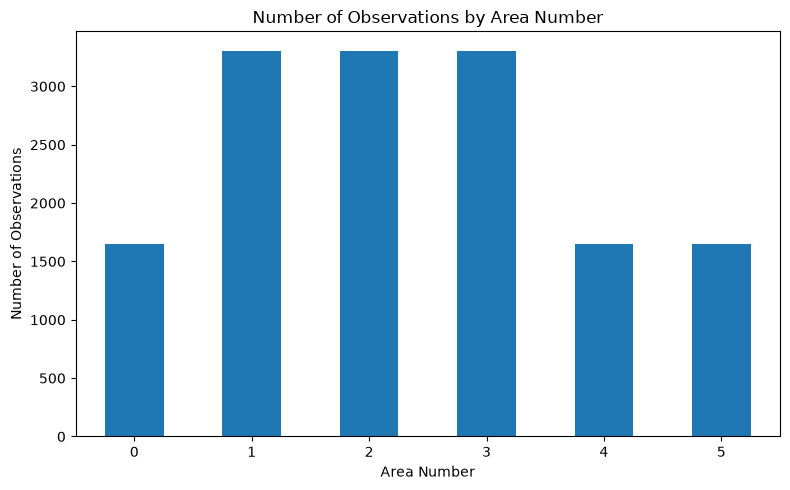

In [75]:
# Plot the number of records associated with each area number.
area_number_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Observations by Area Number")
plt.xlabel("Area Number")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.3 Reservoir Measurement Variables

The dataset contains identifiers, dates, categorical variables, and numerical
reservoir measurements.

For continuous-data visualisation, the following reservoir measurement
variables are used:

- `fill_level`
- `capacity_TWh`
- `stored_energy_TWh`
- `previous_week_fill_level`
- `change_in_fill_level`

Variables such as `year`, `week`, and `area_number` are primarily identifiers or
time descriptors and are therefore not treated as reservoir measurements.

In [76]:
# Define the continuous reservoir variables used in the main visualisations.
measurement_columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "previous_week_fill_level",
    "change_in_fill_level",
]

# Display descriptive statistics for these variables only.
reservior_df[measurement_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fill_level,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
capacity_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
stored_energy_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
previous_week_fill_level,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
change_in_fill_level,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623


## 8. Individual Variable Visualisations

Each reservoir measurement is plotted separately to make its temporal behaviour
easier to inspect.

Separate plots are useful because the variables have different units and
numerical ranges. Plotting them individually avoids one variable dominating
another because of scale differences.

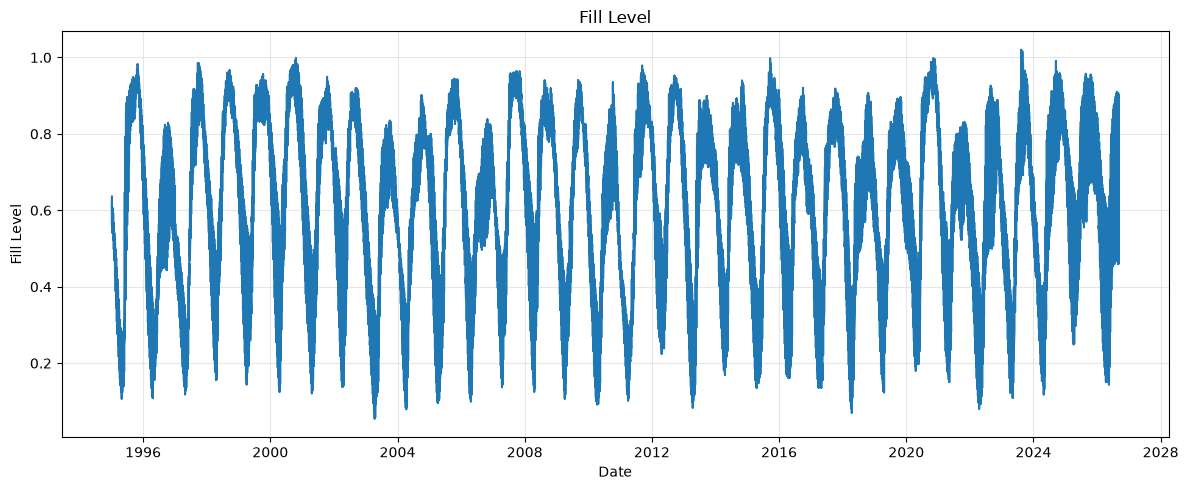

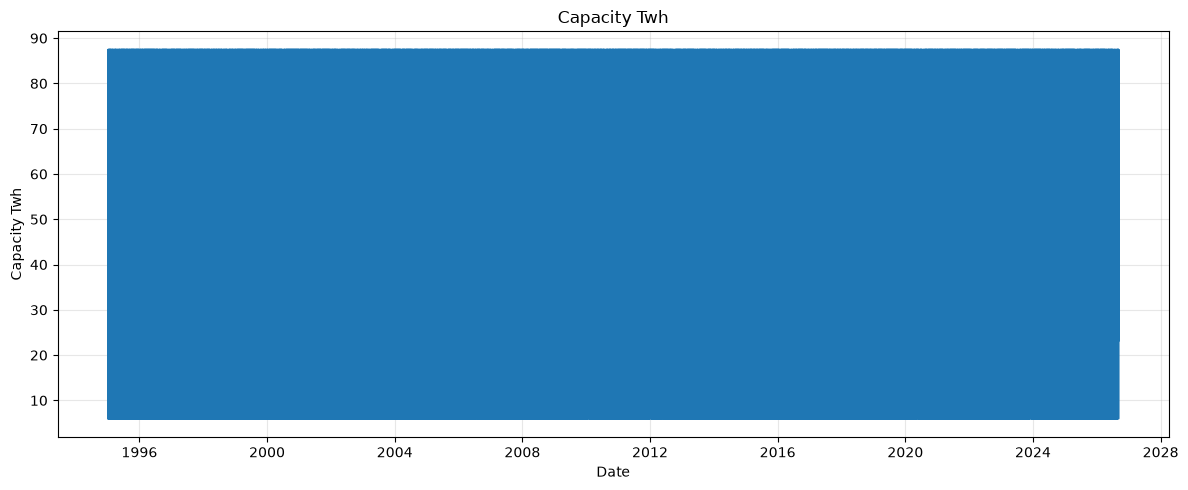

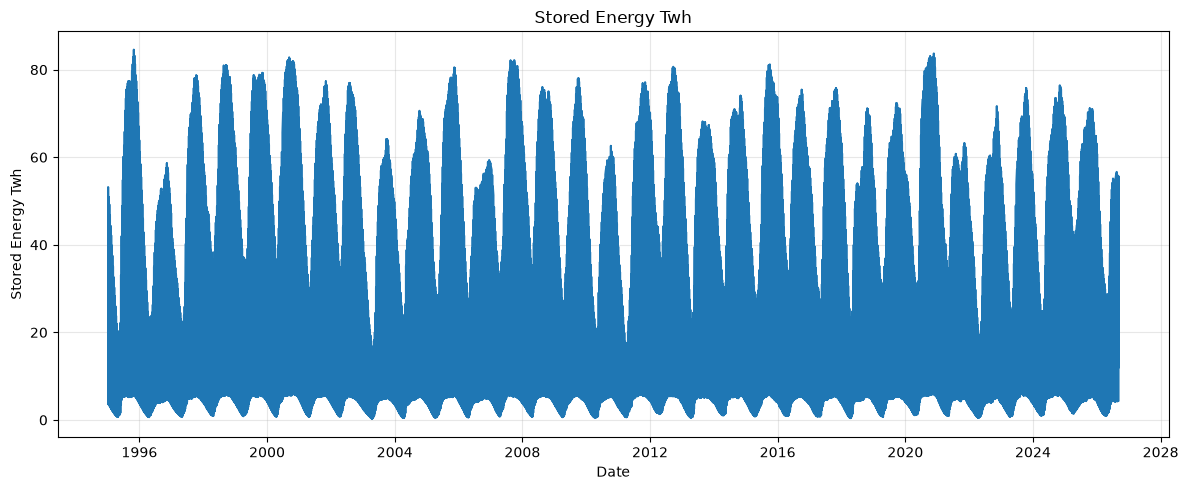

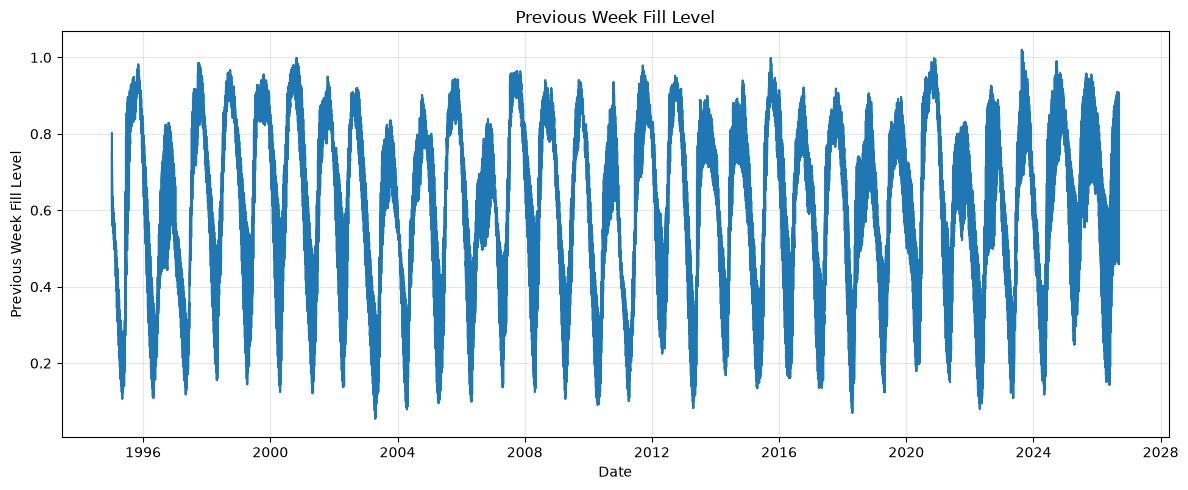

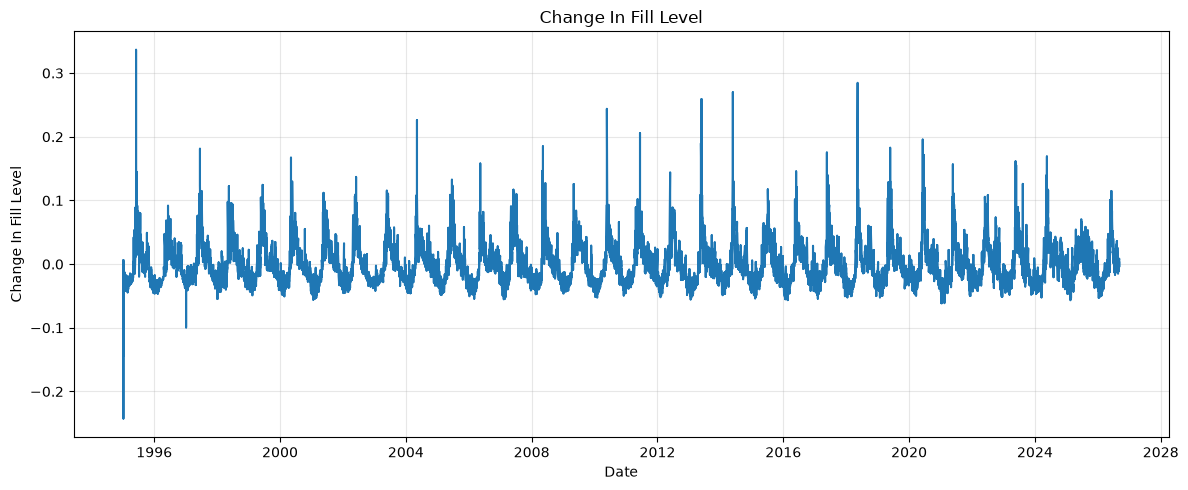

In [77]:
# Plot each continuous reservoir measurement in its own figure.
for column in measurement_columns:
    plt.figure(figsize=(12, 5))

    plt.plot(
        reservior_df["date"],
        reservior_df[column]
    )

    plt.title(column.replace("_", " ").title())
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### 8.1 Aggregated Time Series

The dataset contains observations from several area categories for the same
week. Plotting every raw row directly would result in several values being
connected at identical dates.

For a clearer overall view, the reservoir measurements are therefore aggregated
by date using the mean.

This produces one representative value per date for each numerical measurement
and makes the temporal trends easier to interpret.

In [78]:
# Select the national reservoir data.
national_df = reservior_df[
    (reservior_df["area_type"] == "NO")
    & (reservior_df["area_number"] == 0)
].copy()

# Calculate the mean for each date.
weekly_mean = (
    national_df.groupby("date")[measurement_columns]
    .mean()
    .sort_index()
)

weekly_mean.head()

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


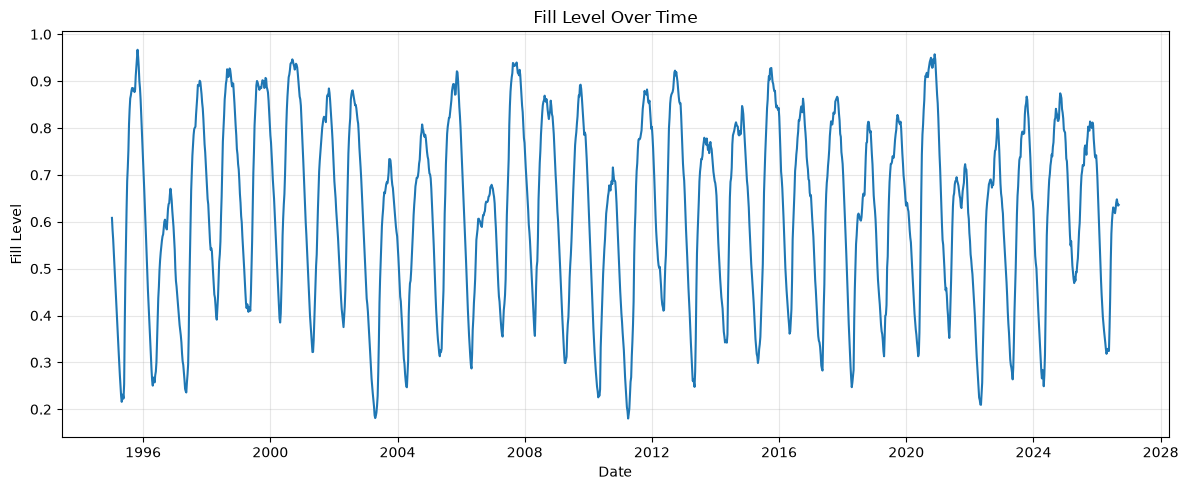

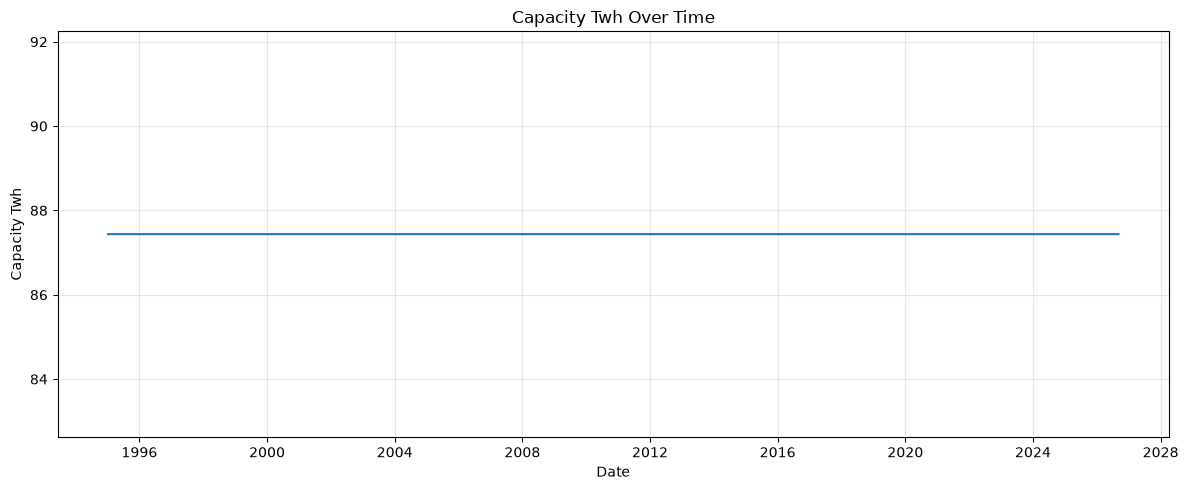

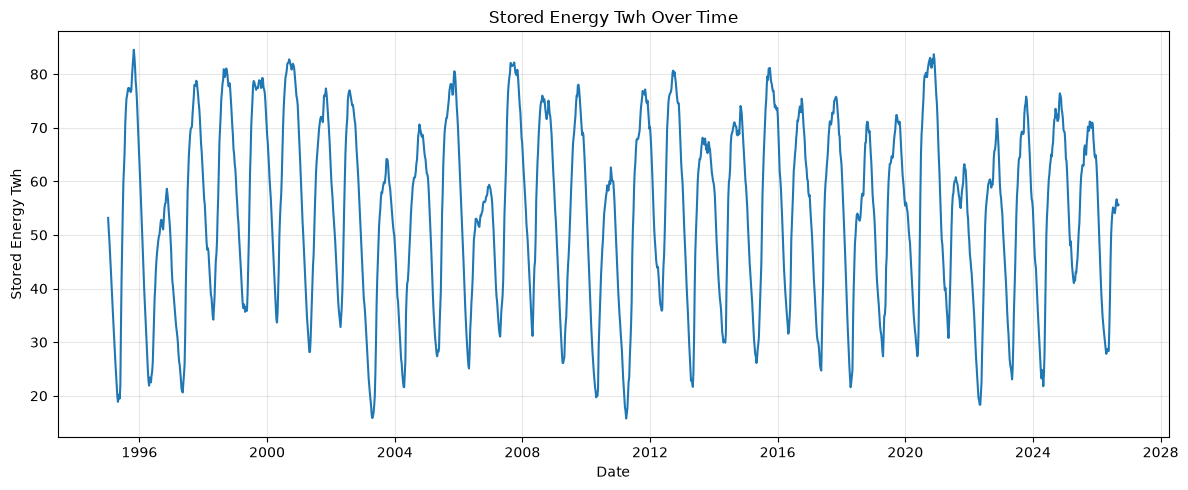

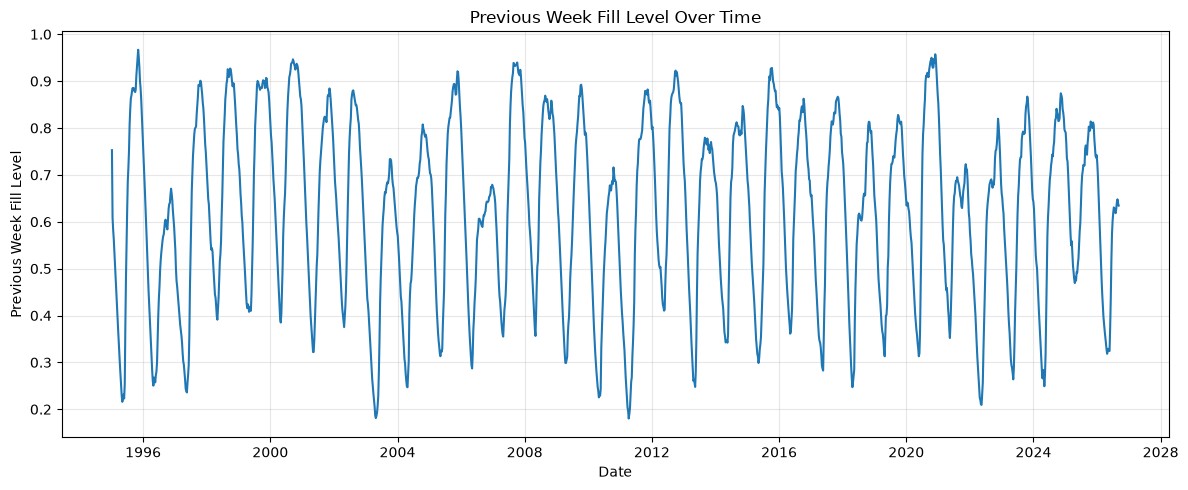

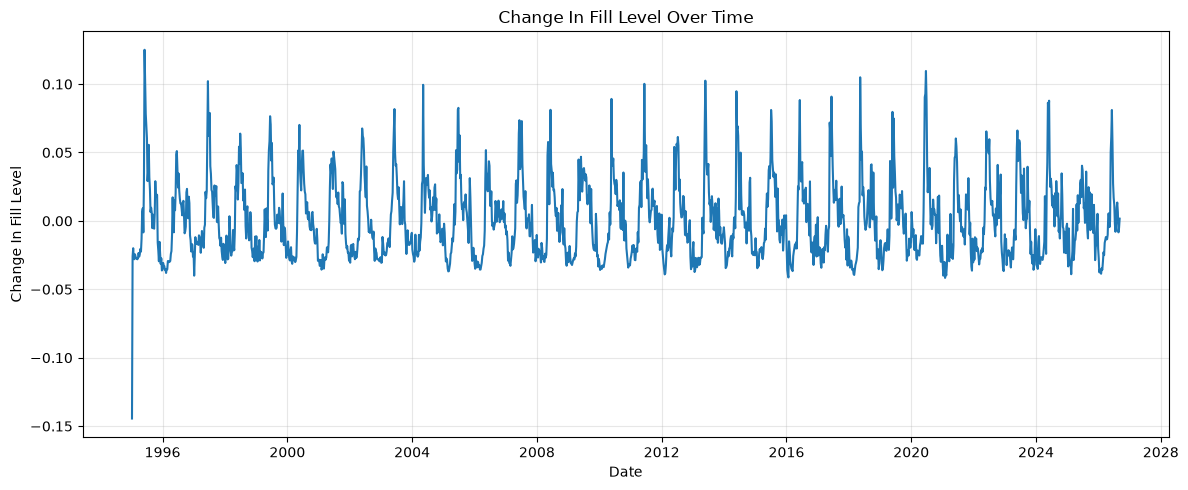

In [79]:
# Plot each aggregated measurement as a separate time series.
for column in measurement_columns:
    plt.figure(figsize=(12, 5))

    plt.plot(
        weekly_mean.index,
        weekly_mean[column]
    )

    plt.title(f"{column.replace('_', ' ').title()} Over Time")
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Combined Visualisation

The reservoir variables have substantially different numerical scales.

For example, a variable expressed in TWh cannot be compared directly on the same axis with a proportional fill-level variable.

To make their temporal patterns visually comparable, Min-Max normalisation is applied to the aggregated measurements.

For each variable, the transformation is:

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

This maps each non-constant series to the range 0–1.

For variables with constant values, where the maximum and minimum are equal, a normalised value of 0.5 is assigned to avoid division by zero.

The transformation is used only for this combined visualisation. The original data remain unchanged.


In [80]:
# Apply Min-Max normalisation independently to each measurement column.
normalized_weekly_mean = (
    (weekly_mean - weekly_mean.min())
    / (weekly_mean.max() - weekly_mean.min()).replace(0, float("nan"))
)

# Assign 0.5 to variables with constant values.
normalized_weekly_mean = normalized_weekly_mean.fillna(0.5)

normalized_weekly_mean.head()

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
date,,,,,
1995-01-08,0.544098,0.5,0.544098,0.727714,0.000000
1995-01-15,0.511173,0.5,0.511173,0.544109,0.439810
1995-01-22,0.485800,0.5,0.485800,0.511204,0.461793
1995-01-29,0.450329,0.5,0.450329,0.485808,0.432379
1995-02-05,0.414707,0.5,0.414707,0.450310,0.432013


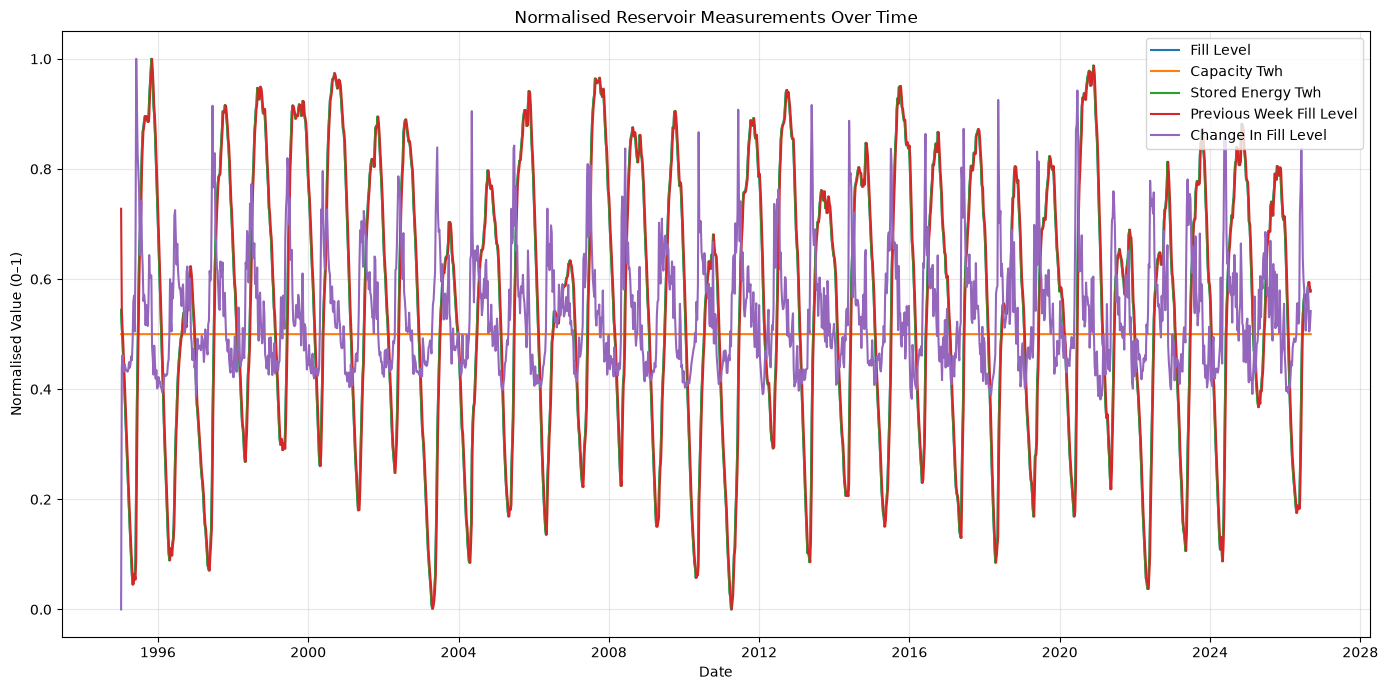

In [81]:
# Plot all normalised reservoir measurements on the same scale.
plt.figure(figsize=(14, 7))

for column in measurement_columns:
    plt.plot(
        normalized_weekly_mean.index,
        normalized_weekly_mean[column],
        label=column.replace("_", " ").title()
    )

plt.title("Normalised Reservoir Measurements Over Time")
plt.xlabel("Date")
plt.ylabel("Normalised Value (0–1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.1 Relationships Between Numerical Measurements

A correlation matrix is used as an additional exploratory step to examine how
the continuous reservoir variables move in relation to one another.

Correlation measures linear association and does not imply causation.

In [82]:
# Calculate Pearson correlations between reservoir measurement variables.
correlation_matrix = reservior_df[measurement_columns].corr()

correlation_matrix

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
fill_level,1.000000,0.021033,0.369088,0.989330,0.073259
capacity_TWh,0.021033,1.000000,0.887986,0.021177,-0.000978
stored_energy_TWh,0.369088,0.887986,1.000000,0.365682,0.023393
previous_week_fill_level,0.989330,0.021177,0.365682,1.000000,-0.072824
change_in_fill_level,0.073259,-0.000978,0.023393,-0.072824,1.000000


## 10. Derived Time Variables

The dataset already contains year and ISO week information.

For exploratory purposes, the calendar month is also derived from the date.
This is useful for monthly filtering and will later support the month-selection
functionality in the Streamlit application.

In [83]:
# Derive month information from the observation date.
reservior_df["month_number"] = reservior_df["date"].dt.month
reservior_df["month_name"] = reservior_df["date"].dt.month_name()

# Inspect the derived variables.
reservior_df[["date", "year", "week", "month_number", "month_name"]].head()

,date,year,week,month_number,month_name
0,1995-01-08,1995,1,1,January
1,1995-01-08,1995,1,1,January
2,1995-01-08,1995,1,1,January
3,1995-01-08,1995,1,1,January
4,1995-01-08,1995,1,1,January


### 10.1 Monthly Reservoir Patterns

To obtain a high-level view of seasonality, reservoir measurements are averaged
by calendar month.

This summary does not replace the weekly data; it provides an additional view
of typical changes across the year.

In [84]:
# Calculate average reservoir measurements for each calendar month.
monthly_summary = (
    reservior_df.groupby("month_number")[measurement_columns]
    .mean()
    .sort_index()
)

monthly_summary

,fill_level,capacity_TWh,stored_energy_TWh,previous_week_fill_level,change_in_fill_level
month_number,,,,,
1,0.619034,29.14586,18.325756,0.645800,-0.026766
2,0.497810,29.14586,14.987228,0.526443,-0.028633
3,0.385994,29.14586,11.882482,0.410784,-0.024790
4,0.307788,29.14586,9.649319,0.319067,-0.011280
5,0.359926,29.14586,10.829130,0.329886,0.030039
6,0.571342,29.14586,16.533804,0.520873,0.050469
7,0.727570,29.14586,20.938909,0.701431,0.026139
8,0.788875,29.14586,22.696154,0.780162,0.008713
9,0.816625,29.14586,23.528835,0.811896,0.004729


## 11. Data Quality Summary

The dataset was inspected for common data-quality issues before being used in
the visualisations.

The checks performed include:

- missing values,
- duplicate observations,
- appropriate date types,
- chronological ordering,
- and sensible numerical summaries.

No aggressive cleaning or machine-learning preprocessing is performed because
the purpose of this stage is exploratory analysis and dashboard development
rather than predictive modelling.

In [85]:
# Produce a compact data-quality summary.
quality_summary = pd.DataFrame({
    "data_type": reservior_df.dtypes.astype(str),
    "missing_values": reservior_df.isna().sum(),
    "unique_values": reservior_df.nunique()
})

quality_summary

,data_type,missing_values,unique_values
date,datetime64[us],0,1653
area_type,str,0,3
area_number,int64,0,6
year,int64,0,32
week,int64,0,53
fill_level,float64,0,14868
capacity_TWh,float64,0,9
stored_energy_TWh,float64,0,14871
next_publication_date,datetime64[us],0,396
previous_week_fill_level,float64,0,14868



## 12. Streamlit Application

The ReservoirScope Streamlit application provides an interactive interface for exploring Norwegian reservoir data.

The application contains four pages:

1. **Home:** Introduces ReservoirScope and provides navigation.
2. **Reservoir Data:** Displays the imported dataset and first-month reservoir measurements using Streamlit's `LineChartColumn()`.
3. **Reservoir Visualisation:** Provides interactive variable selection, month-range filtering and time-series visualisation.
4. **Project Information:** Documents the project objectives, features, technologies and data processing.

The application reads the local CSV file using Pandas and uses `st.cache_data` to improve data-loading performance.

The interactive visualisation uses national reservoir observations. Min-Max normalisation is applied when comparing measurements with different numerical scales. Constant variables are handled separately to avoid division by zero.

The source code is hosted on GitHub. The application is intended to be deployed through Streamlit Community Cloud.


## 13. Project Links

**GitHub Repository:**  
https://github.com/Zawaril/ReservoirScope

**Streamlit Application:**  
https://reservoirscope.streamlit.app/

## 14. AI Usage

AI tools were used as a development assistant during this project.

The assistance included:

- clarifying assignment requirements,
- suggesting a logical notebook structure,
- explaining Pandas and Streamlit functionality,
- helping improve code comments and documentation,
- assisting with debugging,
- and reviewing code for readability and reproducibility.

AI-generated suggestions were reviewed and adapted before being included in the
project. The dataset analysis, implementation decisions, testing, and final
project submission remain my responsibility.


## 15. Development Log

The development of ReservoirScope began with importing the `reservoirs.csv` dataset into a Jupyter Notebook using Pandas. I first inspected the dataset to understand its structure, variable types, missing values and geographical coverage. The dataset contains 14,877 observations from 1995 to 2026. I translated the original Norwegian column names into descriptive English names and converted the observation dates into datetime format to make the data easier to analyse.

During the exploratory analysis, I examined the numerical variables and created separate plots to understand their distributions and changes over time. One challenge was that the measurements use different scales. For example, fill level is expressed as a proportion, while capacity and stored energy are expressed in TWh. Plotting these variables directly on the same axis made some patterns difficult to identify. I therefore applied Min-Max normalisation to the combined visualisation. I also handled constant variables to avoid division by zero. Another observation was that national fill level and stored energy follow almost identical normalised patterns because stored energy depends on fill level and capacity.

After completing the notebook analysis, I developed ReservoirScope as a multi-page Streamlit application. I created four pages: Home, Reservoir Data, Reservoir Visualisation and Project Information. The Reservoir Data page displays the imported dataset and first-month measurements using Streamlit's `LineChartColumn()`. The Reservoir Visualisation page allows users to select a measurement using `st.selectbox()` and filter the date range using `st.select_slider()`. It also provides a combined normalised plot for comparing different measurements.

I used `st.cache_data` to reduce repeated CSV loading and improve the application's performance. I also used Matplotlib to customise the plots and Streamlit's theme configuration to maintain a consistent appearance across the application. During development, I adjusted the plotting order and line styles because some normalised measurements overlapped, making individual lines difficult to see.

I used GitHub for version control and to organise the notebook, application files and dependencies. I then deployed the application using Streamlit Community Cloud to make it publicly accessible. I tested the pages and interactive controls to check that the deployed application behaved as expected.

This project helped me connect exploratory data analysis with interactive application development. I gained practical experience in preparing real-world data, choosing suitable visualisations, handling numerical scaling and organising a Python project for deployment. I also learned the importance of checking whether a visualisation accurately represents the underlying data.


## 16. Conclusion

This notebook prepared and explored the reservoir dataset used by
ReservoirScope.

The raw data were inspected, renamed using clear English headers, converted into
appropriate data types, and examined for missing and duplicate observations.

Exploratory analysis was then used to investigate the dataset's geographical,
temporal, and numerical structure. Reservoir measurements were visualised
individually, while normalisation was used to compare variables with different
scales in a combined plot.

The resulting data preparation and analysis provide the foundation for the
interactive ReservoirScope Streamlit application.